## Image Processing Sample Code

To run this notebook you will just need the following packages installed: opencv, numpy, and matplotlib

In [1]:
# Load modules
from app.services.image_processing import read_image, segment_hough, segment_rect
from app.services.visualize import create_segmentation_gif, create_mean_value_image
import matplotlib.pyplot as plt

<Figure size 800x800 with 0 Axes>

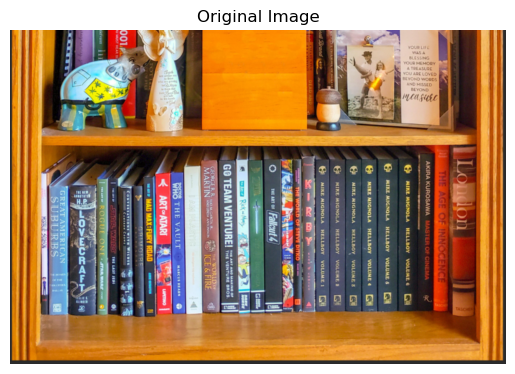

In [34]:
# Choose image
image_path = "images/archive/bookshelf10.png"

# Read and display
image = read_image(image_path, max_dim=1024)

plt.figure(figsize=(8, 8))
fig, ax = plt.subplots()
ax.axis("off")
ax.set_title("Original Image")
ax.imshow(image)
plt.show()

Depth 0 | Split 1: score=0.028, child pixels=342953, 288183, child ratios=0.54, 0.46
Depth 1 | Split 2: score=0.085, child pixels=120742, 222211, child ratios=0.35, 0.65
Depth 2 | Split 3: score=0.144, child pixels=113674, 7068, child ratios=0.94, 0.06
Depth 3 | Split 4: score=0.079, child pixels=93112, 20562, child ratios=0.82, 0.18
Depth 4 | Split 5: score=0.083, child pixels=73243, 19869, child ratios=0.79, 0.21
Depth 5 | Split 6: score=0.386, child pixels=14703, 58540, child ratios=0.20, 0.80
Depth 2 | Split 7: score=0.097, child pixels=115363, 106848, child ratios=0.52, 0.48
Depth 3 | Split 8: score=0.170, child pixels=89075, 26288, child ratios=0.77, 0.23
Depth 4 | Split 9: score=0.265, child pixels=65331, 23744, child ratios=0.73, 0.27
Depth 5 | Split 10: score=0.136, child pixels=45827, 19504, child ratios=0.70, 0.30
Depth 3 | Split 11: score=0.087, child pixels=85224, 21624, child ratios=0.80, 0.20
Depth 4 | Split 12: score=0.146, child pixels=34974, 50250, child ratios=0.41, 

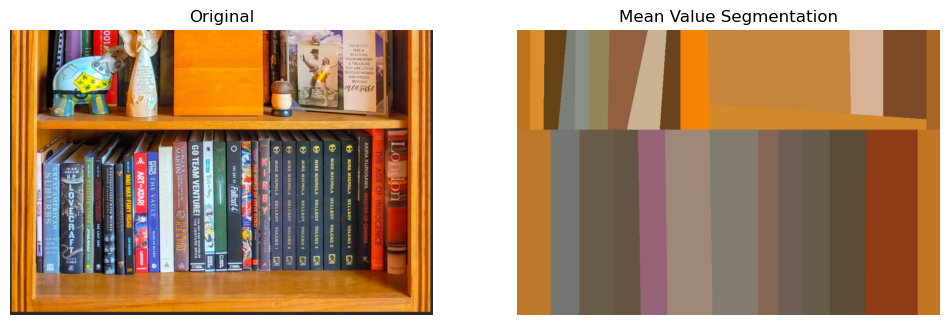

GIF saved to images/gifs/hough_segmentation.gif (11 frames)


In [35]:
# Rectangular segmentation with verbose output
seg_hough = segment_hough(
    image,
    verbose=True,
    nlm_h=20,
    nlm_patch_size=15,
    nlm_search_size=45,
    min_score=0.01,
)

# Create mean-value visualization (still image)
mean_img_hough = create_mean_value_image(image, seg_hough.masks)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(mean_img_hough)
plt.title('Mean Value Segmentation')
plt.axis('off')
plt.show()

# Create GIF
create_segmentation_gif(
    image,
    seg_hough,
    output_path='images/gifs/hough_segmentation.gif',
    duration=300,
    final_duration=2000,
    boundary_color=(255, 165, 0),
    highlight_idx=34  # Optional: highlight specific segment
)

Depth 0 | Split 1: score=0.724, direction=vertical, pos=62, child ratios=0.06, 0.94
Depth 1 | Split 2: score=0.799, direction=vertical, pos=919, child ratios=0.95, 0.05
Depth 2 | Split 3: score=0.765, direction=vertical, pos=114, child ratios=0.06, 0.94
Depth 3 | Split 4: score=0.611, direction=vertical, pos=191, child ratios=0.10, 0.90
Depth 4 | Split 5: score=0.566, direction=vertical, pos=238, child ratios=0.06, 0.94
Depth 5 | Split 6: score=0.562, direction=vertical, pos=340, child ratios=0.15, 0.85
Depth 6 | Split 7: score=0.517, direction=vertical, pos=407, child ratios=0.12, 0.88
Depth 7 | Split 8: score=0.521, direction=vertical, pos=444, child ratios=0.07, 0.93
Depth 8 | Split 9: score=0.506, direction=horizontal, pos=227, child ratios=0.35, 0.65
Depth 9 | Split 10: score=1.337, direction=vertical, pos=836, child ratios=0.83, 0.17
Depth 9 | Split 11: score=0.966, direction=vertical, pos=496, child ratios=0.11, 0.89

Total segments: 12


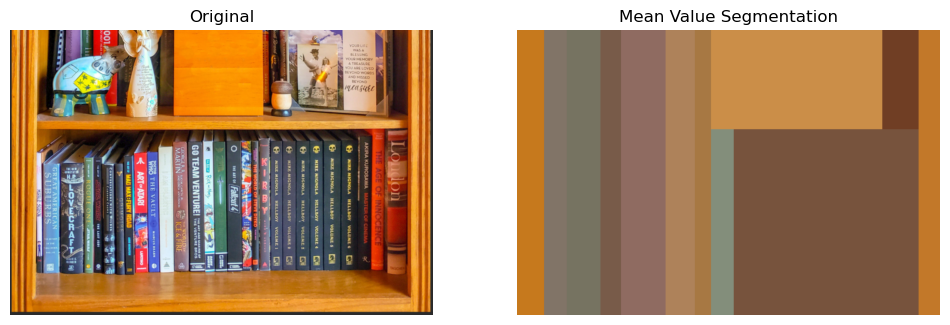

GIF saved to images/gifs/rect_segmentation.gif (13 frames)


In [36]:
# Rectangular segmentation with verbose output
seg_rect = segment_rect(
    image, 
    min_size_factor=None,
    score_threshold=0.2,
    verbose=True
)

# Create mean-value visualization (still image)
mean_img_rect = create_mean_value_image(image, seg_rect.masks)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(mean_img_rect)
plt.title('Mean Value Segmentation')
plt.axis('off')
plt.show()

# Create GIF
create_segmentation_gif(
    image,
    seg_rect,
    output_path='images/gifs/rect_segmentation.gif',
    duration=300,
    final_duration=2000,
    boundary_color=(255, 165, 0),
    highlight_idx=0
)